Dataset shape: (569, 30)
Number of input features: 30

Class definition:
0 = Benign
1 = Malignant

Number of Benign samples: 357
Number of Malignant samples: 212

Training samples: 455
Validation/Test samples: 114

Number of features used for classification: 30


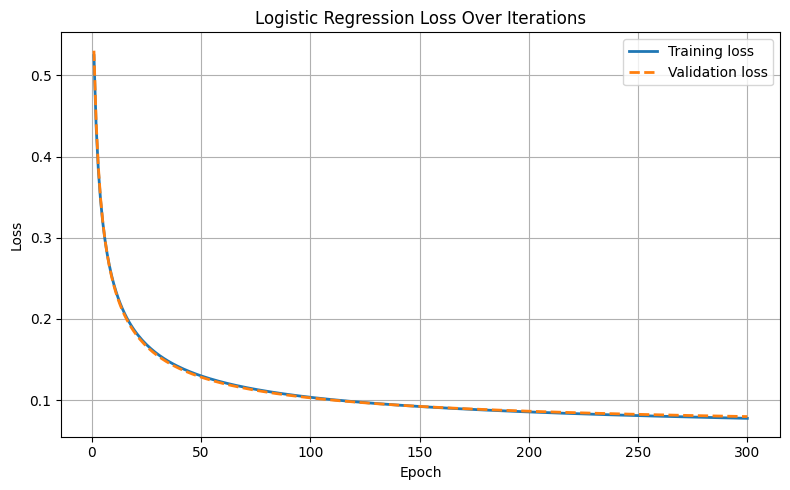

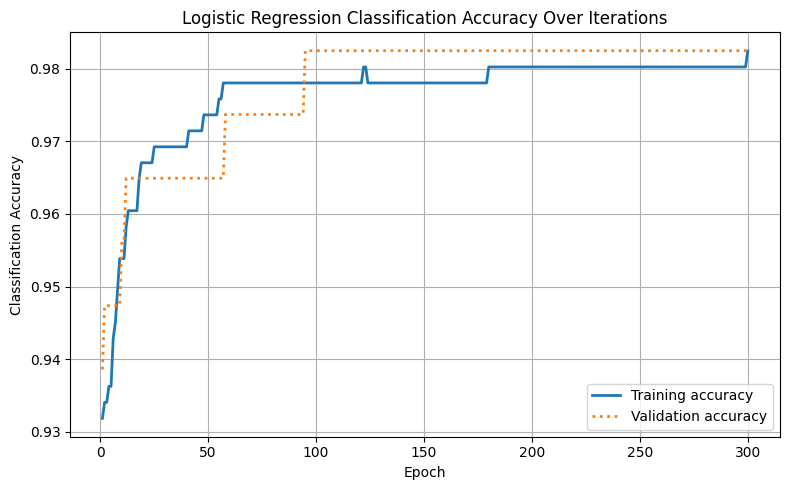


Final Evaluation(Test) Results
--------------------------------
Accuracy  : 0.9825
Precision : 1.0000
Recall    : 0.9524
F1 Score  : 0.9756

Percentage Form
--------------------------------
Accuracy  : 98.25%
Precision : 100.00%
Recall    : 95.24%
F1 Score  : 97.56%

Confusion Matrix:
[[72  0]
 [ 2 40]]


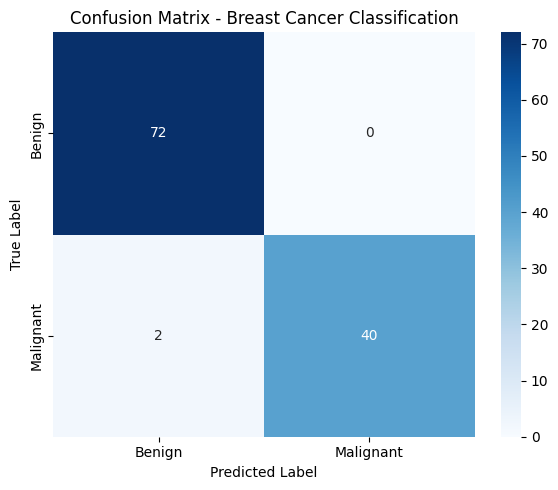

In [3]:
# ============================================================
# HOMEWORK 3 - PROBLEM 2, PART 1
# Logistic Regression for Breast Cancer Classification
# Using All 30 Input Features
#
# Class definition:
# 0 = Benign
# 1 = Malignant
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. Load Breast Cancer Dataset
# ============================================================

cancer = load_breast_cancer()

X = cancer.data

# sklearn originally defines:
# 0 = Malignant
# 1 = Benign
#
# Reverse the labels so that:
# 0 = Benign
# 1 = Malignant

y = (cancer.target == 0).astype(int)


# ============================================================
# 2. Display Dataset Information
# ============================================================

print("Dataset shape:", X.shape)
print("Number of input features:", X.shape[1])

print("\nClass definition:")
print("0 = Benign")
print("1 = Malignant")

print("\nNumber of Benign samples:", np.sum(y == 0))
print("Number of Malignant samples:", np.sum(y == 1))


# ============================================================
# 3. 80% Training / 20% Evaluation(Test) Split
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Validation/Test samples:", X_val.shape[0])


# ============================================================
# 4. Feature Scaling / Standardization
# ============================================================

scaler = StandardScaler()

# Fit scaler only on training data
X_train = scaler.fit_transform(X_train)

# Apply same transformation to validation/test data
X_val = scaler.transform(X_val)


# ============================================================
# 5. Logistic Regression Helper Functions
# ============================================================

def sigmoid(z):

    # Avoid numerical overflow
    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y_true, y_probability):

    epsilon = 1e-15

    y_probability = np.clip(
        y_probability,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_true * np.log(y_probability)
        +
        (1 - y_true) * np.log(1 - y_probability)
    )

    return loss


# ============================================================
# 6. Initialize Parameters
# ============================================================

number_of_features = X_train.shape[1]

print(
    "\nNumber of features used for classification:",
    number_of_features
)

weights = np.zeros(number_of_features)
bias = 0.0

learning_rate = 0.1
number_of_iterations = 300


# ============================================================
# 7. Store Training Results
# ============================================================

training_loss_history = []
validation_loss_history = []

training_accuracy_history = []
validation_accuracy_history = []


# ============================================================
# 8. Train Logistic Regression Using Gradient Descent
# ============================================================

m = X_train.shape[0]

for iteration in range(number_of_iterations):

    # --------------------------------------------------------
    # Forward pass on training data
    # --------------------------------------------------------

    z_train = np.dot(X_train, weights) + bias

    y_train_probability = sigmoid(
        z_train
    )


    # --------------------------------------------------------
    # Compute gradient
    # --------------------------------------------------------

    error = (
        y_train_probability
        - y_train
    )

    dw = (
        1 / m
    ) * np.dot(
        X_train.T,
        error
    )

    db = (
        1 / m
    ) * np.sum(
        error
    )


    # --------------------------------------------------------
    # Gradient descent update
    # --------------------------------------------------------

    weights = (
        weights
        - learning_rate * dw
    )

    bias = (
        bias
        - learning_rate * db
    )


    # ========================================================
    # Training Results
    # ========================================================

    z_train = np.dot(
        X_train,
        weights
    ) + bias

    y_train_probability = sigmoid(
        z_train
    )

    y_train_prediction = (
        y_train_probability >= 0.5
    ).astype(int)


    training_loss = binary_cross_entropy(
        y_train,
        y_train_probability
    )

    training_accuracy = accuracy_score(
        y_train,
        y_train_prediction
    )


    # ========================================================
    # Validation Results
    # ========================================================

    z_val = np.dot(
        X_val,
        weights
    ) + bias

    y_val_probability = sigmoid(
        z_val
    )

    y_val_prediction = (
        y_val_probability >= 0.5
    ).astype(int)


    validation_loss = binary_cross_entropy(
        y_val,
        y_val_probability
    )

    validation_accuracy = accuracy_score(
        y_val,
        y_val_prediction
    )


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    training_loss_history.append(
        training_loss
    )

    validation_loss_history.append(
        validation_loss
    )

    training_accuracy_history.append(
        training_accuracy
    )

    validation_accuracy_history.append(
        validation_accuracy
    )


# ============================================================
# 9. Plot Training and Validation Loss
# ============================================================

plt.figure(figsize=(8, 5))

# Training loss - solid line
plt.plot(
    range(1, number_of_iterations + 1),
    training_loss_history,
    linestyle='-',
    linewidth=2,
    label='Training loss'
)

# Validation loss - dashed line
plt.plot(
    range(1, number_of_iterations + 1),
    validation_loss_history,
    linestyle='--',
    linewidth=2,
    label='Validation loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Logistic Regression Loss Over Iterations'
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 10. Plot Training and Validation Classification Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

# Training accuracy - solid line
plt.plot(
    range(1, number_of_iterations + 1),
    training_accuracy_history,
    linestyle='-',
    linewidth=2,
    label='Training accuracy'
)

# Validation accuracy - dotted line
plt.plot(
    range(1, number_of_iterations + 1),
    validation_accuracy_history,
    linestyle=':',
    linewidth=2,
    label='Validation accuracy'
)

plt.xlabel('Epoch')

plt.ylabel(
    'Classification Accuracy'
)

plt.title(
    'Logistic Regression Classification Accuracy Over Iterations'
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 11. Final Prediction on Evaluation/Test Set
# ============================================================

z_val = np.dot(
    X_val,
    weights
) + bias

y_val_probability = sigmoid(
    z_val
)

y_pred = (
    y_val_probability >= 0.5
).astype(int)


# ============================================================
# 12. Final Evaluation Metrics
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred
)

recall = recall_score(
    y_val,
    y_pred
)

f1 = f1_score(
    y_val,
    y_pred
)


print("\nFinal Evaluation(Test) Results")
print("--------------------------------")

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)


print("\nPercentage Form")
print("--------------------------------")

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)


# ============================================================
# 13. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_val,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 14. Plot Confusion Matrix
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=[
        'Benign',
        'Malignant'
    ],
    yticklabels=[
        'Benign',
        'Malignant'
    ]
)

plt.title(
    'Confusion Matrix - Breast Cancer Classification'
)

plt.xlabel(
    'Predicted Label'
)

plt.ylabel(
    'True Label'
)

plt.tight_layout()

plt.show()

Dataset shape: (569, 30)
Number of input features: 30

Class definition:
0 = Benign
1 = Malignant

Number of Benign samples: 357
Number of Malignant samples: 212

Training samples: 455
Validation/Test samples: 114

Number of features used for classification: 30
Regularization parameter (lambda): 5.0


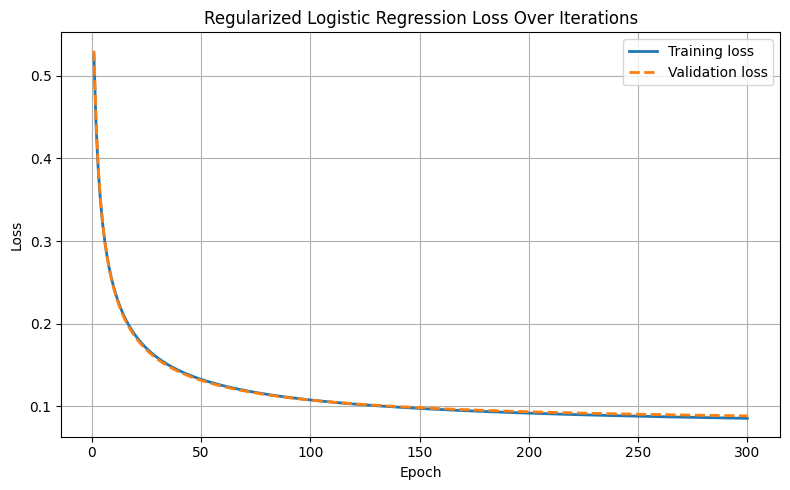

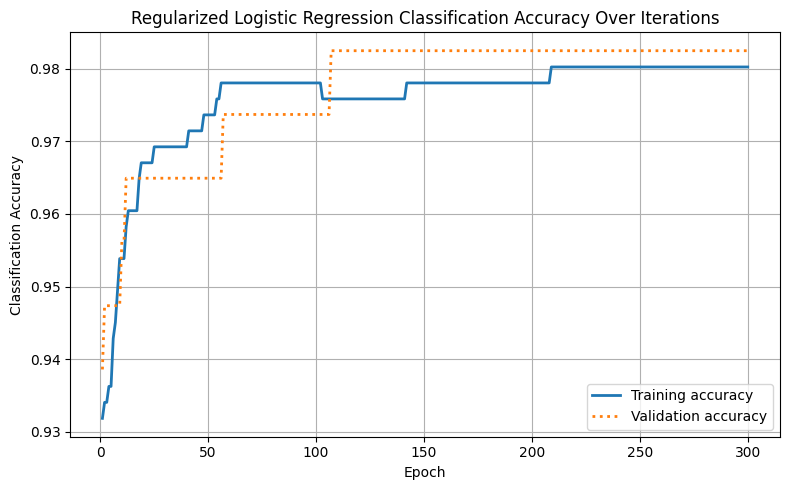


Regularized Logistic Regression Results
----------------------------------------
Accuracy  : 0.9825
Precision : 1.0000
Recall    : 0.9524
F1 Score  : 0.9756

Percentage Form
----------------------------------------
Accuracy  : 98.25%
Precision : 100.00%
Recall    : 95.24%
F1 Score  : 97.56%

Regularization Information
----------------------------------------
Lambda                      : 5.0
Final Training BCE Loss      : 0.085360
Final L2 Weight Penalty      : 0.020482
Final Regularized Objective  : 0.105842
L2 Norm of Weight Vector     : 1.930730

Confusion Matrix:
[[72  0]
 [ 2 40]]


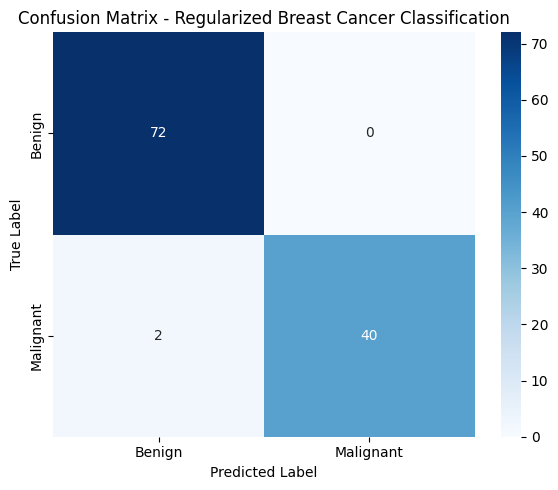

In [6]:
# ============================================================
# HOMEWORK 3 - PROBLEM 2, PART 2
# Regularized Logistic Regression for Breast Cancer
# Using All 30 Input Features
#
# L2 Weight Penalty
#
# Class definition:
# 0 = Benign
# 1 = Malignant
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. Load Breast Cancer Dataset
# ============================================================

cancer = load_breast_cancer()

X = cancer.data

# sklearn originally uses:
# 0 = Malignant
# 1 = Benign
#
# Reverse labels so that the positive class is:
# 0 = Benign
# 1 = Malignant

y = (cancer.target == 0).astype(int)


# ============================================================
# 2. Display Dataset Information
# ============================================================

print("Dataset shape:", X.shape)
print("Number of input features:", X.shape[1])

print("\nClass definition:")
print("0 = Benign")
print("1 = Malignant")

print("\nNumber of Benign samples:", np.sum(y == 0))
print("Number of Malignant samples:", np.sum(y == 1))


# ============================================================
# 3. 80% Training / 20% Evaluation(Test) Split
#
# Same split as Problem 2 Part 1
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Validation/Test samples:", X_val.shape[0])


# ============================================================
# 4. Feature Scaling / Standardization
# ============================================================

scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train = scaler.fit_transform(X_train)

# Apply same transformation to validation/test data
X_val = scaler.transform(X_val)


# ============================================================
# 5. Logistic Regression Functions
# ============================================================

def sigmoid(z):

    # Prevent numerical overflow
    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y_true, y_probability):

    epsilon = 1e-15

    y_probability = np.clip(
        y_probability,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_true * np.log(y_probability)
        +
        (1 - y_true) * np.log(1 - y_probability)
    )

    return loss


# ============================================================
# 6. Initialize Parameters
# ============================================================

number_of_features = X_train.shape[1]

print(
    "\nNumber of features used for classification:",
    number_of_features
)

weights = np.zeros(number_of_features)

# Bias is separate because it is NOT regularized
bias = 0.0

learning_rate = 0.1
number_of_iterations = 300


# ============================================================
# 7. Regularization Parameter
# ============================================================

# L2 regularization strength
lambda_reg = 5.0

print(
    "Regularization parameter (lambda):",
    lambda_reg
)


# ============================================================
# 8. Store Training Results
# ============================================================

training_loss_history = []
validation_loss_history = []

training_accuracy_history = []
validation_accuracy_history = []

# Store the actual regularized training objective:
#
# J_regularized =
# BCE + lambda/(2m) * sum(weights^2)

regularized_objective_history = []


# ============================================================
# 9. Train Regularized Logistic Regression
# ============================================================

m = X_train.shape[0]


for iteration in range(number_of_iterations):

    # --------------------------------------------------------
    # Forward Pass
    # --------------------------------------------------------

    z_train = (
        np.dot(X_train, weights)
        + bias
    )

    y_train_probability = sigmoid(
        z_train
    )


    # --------------------------------------------------------
    # Prediction Error
    # --------------------------------------------------------

    error = (
        y_train_probability
        - y_train
    )


    # --------------------------------------------------------
    # Ordinary Logistic Regression Gradient
    #
    # (1/m) X^T (prediction - true label)
    # --------------------------------------------------------

    data_gradient = (
        1 / m
    ) * np.dot(
        X_train.T,
        error
    )


    # --------------------------------------------------------
    # L2 Weight Penalty Gradient
    #
    # (lambda/m) * weights
    #
    # Bias is NOT included.
    # --------------------------------------------------------

    regularization_gradient = (
        lambda_reg / m
    ) * weights


    # --------------------------------------------------------
    # Total Weight Gradient
    # --------------------------------------------------------

    dw = (
        data_gradient
        +
        regularization_gradient
    )


    # --------------------------------------------------------
    # Bias Gradient
    #
    # No regularization on bias
    # --------------------------------------------------------

    db = (
        1 / m
    ) * np.sum(
        error
    )


    # --------------------------------------------------------
    # Gradient Descent Update
    # --------------------------------------------------------

    weights = (
        weights
        - learning_rate * dw
    )

    bias = (
        bias
        - learning_rate * db
    )


    # ========================================================
    # Training Results After Update
    # ========================================================

    z_train = (
        np.dot(X_train, weights)
        + bias
    )

    y_train_probability = sigmoid(
        z_train
    )

    y_train_prediction = (
        y_train_probability >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # Binary Cross-Entropy Training Loss
    #
    # This is plotted so that it can be directly compared
    # with validation BCE loss.
    # --------------------------------------------------------

    training_bce = binary_cross_entropy(
        y_train,
        y_train_probability
    )


    # --------------------------------------------------------
    # L2 Weight Penalty
    #
    # lambda/(2m) * sum(w_j^2)
    # --------------------------------------------------------

    l2_penalty = (
        lambda_reg / (2 * m)
    ) * np.sum(
        weights ** 2
    )


    # --------------------------------------------------------
    # Full Regularized Training Objective
    #
    # J_regularized = BCE + L2 penalty
    # --------------------------------------------------------

    regularized_training_objective = (
        training_bce
        +
        l2_penalty
    )


    training_accuracy = accuracy_score(
        y_train,
        y_train_prediction
    )


    # ========================================================
    # Validation Results
    # ========================================================

    z_val = (
        np.dot(X_val, weights)
        + bias
    )

    y_val_probability = sigmoid(
        z_val
    )

    y_val_prediction = (
        y_val_probability >= 0.5
    ).astype(int)


    # Validation loss is BCE only.
    # We do NOT add a weight penalty to validation loss.

    validation_bce = binary_cross_entropy(
        y_val,
        y_val_probability
    )


    validation_accuracy = accuracy_score(
        y_val,
        y_val_prediction
    )


    # ========================================================
    # Save Results
    # ========================================================

    training_loss_history.append(
        training_bce
    )

    validation_loss_history.append(
        validation_bce
    )

    regularized_objective_history.append(
        regularized_training_objective
    )

    training_accuracy_history.append(
        training_accuracy
    )

    validation_accuracy_history.append(
        validation_accuracy
    )


# ============================================================
# 10. Plot Training and Validation Loss
#
# Both curves use Binary Cross-Entropy so they are directly
# comparable, as in the lecture learning-curve examples.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, number_of_iterations + 1),
    training_loss_history,
    linestyle='-',
    linewidth=2,
    label='Training loss'
)

plt.plot(
    range(1, number_of_iterations + 1),
    validation_loss_history,
    linestyle='--',
    linewidth=2,
    label='Validation loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Regularized Logistic Regression Loss Over Iterations'
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


# ============================================================
# 11. Plot Training and Validation Classification Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, number_of_iterations + 1),
    training_accuracy_history,
    linestyle='-',
    linewidth=2,
    label='Training accuracy'
)

plt.plot(
    range(1, number_of_iterations + 1),
    validation_accuracy_history,
    linestyle=':',
    linewidth=2,
    label='Validation accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy')

plt.title(
    'Regularized Logistic Regression Classification Accuracy Over Iterations'
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


# ============================================================
# 12. Final Prediction on Evaluation/Test Set
# ============================================================

z_val = (
    np.dot(X_val, weights)
    + bias
)

y_val_probability = sigmoid(
    z_val
)

y_pred = (
    y_val_probability >= 0.5
).astype(int)


# ============================================================
# 13. Evaluation Metrics
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred
)

recall = recall_score(
    y_val,
    y_pred
)

f1 = f1_score(
    y_val,
    y_pred
)


# ============================================================
# 14. Report Results
# ============================================================

print("\nRegularized Logistic Regression Results")
print("----------------------------------------")

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)


print("\nPercentage Form")
print("----------------------------------------")

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)


# ============================================================
# 15. Report Regularization Information
# ============================================================

final_training_bce = training_loss_history[-1]

final_l2_penalty = (
    lambda_reg / (2 * m)
) * np.sum(
    weights ** 2
)

final_regularized_objective = (
    final_training_bce
    +
    final_l2_penalty
)

weight_norm = np.linalg.norm(
    weights
)


print("\nRegularization Information")
print("----------------------------------------")

print(
    f"Lambda                      : {lambda_reg}"
)

print(
    f"Final Training BCE Loss      : "
    f"{final_training_bce:.6f}"
)

print(
    f"Final L2 Weight Penalty      : "
    f"{final_l2_penalty:.6f}"
)

print(
    f"Final Regularized Objective  : "
    f"{final_regularized_objective:.6f}"
)

print(
    f"L2 Norm of Weight Vector     : "
    f"{weight_norm:.6f}"
)


# ============================================================
# 16. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_val,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 17. Plot Confusion Matrix
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=[
        'Benign',
        'Malignant'
    ],
    yticklabels=[
        'Benign',
        'Malignant'
    ]
)

plt.title(
    'Confusion Matrix - Regularized Breast Cancer Classification'
)

plt.xlabel(
    'Predicted Label'
)

plt.ylabel(
    'True Label'
)

plt.tight_layout()

plt.show()